In [33]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, balanced_accuracy_score,
    matthews_corrcoef, precision_recall_curve
)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [34]:
# Load the dataset.
df_raw = pd.read_csv("Telco-Customer-Churn.csv")

# Quick sanity checks.
print(f"Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")
print("\nTarget distribution (%):")
print((df_raw['Churn'].value_counts(normalize=True) * 100).round(2))
df_raw.head()

Rows: 7043, Columns: 21

Target distribution (%):
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
# Review schema and key data quality metrics before preprocessing.
df_raw.info()
print("\nMissing values (top 10):")
print(df_raw.isna().sum().sort_values(ascending=False).head(10))
print(f"\nDuplicate rows: {df_raw.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [36]:
# Create a working copy so the raw data remains unchanged.
df = df_raw.copy()

# Remove duplicate customer records, if any.
df = df.drop_duplicates()

# Strip whitespace from object columns to prevent hidden category mismatches.
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    df[col] = df[col].astype(str).str.strip()

# Convert TotalCharges to numeric and impute invalid/missing values with median.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop identifier column because it does not carry predictive signal.
df = df.drop(columns=['customerID'])

print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (7043, 20)


In [37]:
# Encode target label as binary values: Yes -> 1, No -> 0.
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode categorical columns. drop_first avoids multicollinearity.
df_model = pd.get_dummies(df, drop_first=True)

# Split features and target.
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print(f"Feature matrix shape before reduction: {X.shape}")

Feature matrix shape before reduction: (7043, 30)


In [38]:
# Split data into train and holdout test sets with stratification.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 5634, Test size: 1409


In [39]:
# Build a deterministic pipeline and evaluate it with stratified cross-validation.
k = min(25, X_train.shape[1])
score_func = lambda X_input, y_input: mutual_info_classif(
    X_input, y_input, random_state=RANDOM_STATE
)

cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=score_func, k=k)),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={'accuracy': 'accuracy', 'f1': 'f1', 'roc_auc': 'roc_auc'},
    n_jobs=-1
 )

print('Cross-Validation Performance (Train Set):')
print(f"Accuracy: {cv_scores['test_accuracy'].mean():.4f} (+/- {cv_scores['test_accuracy'].std():.4f})")
print(f"F1 Score: {cv_scores['test_f1'].mean():.4f} (+/- {cv_scores['test_f1'].std():.4f})")
print(f"ROC AUC: {cv_scores['test_roc_auc'].mean():.4f} (+/- {cv_scores['test_roc_auc'].std():.4f})")

Cross-Validation Performance (Train Set):
Accuracy: 0.7483 (+/- 0.0136)
F1 Score: 0.6292 (+/- 0.0213)
ROC AUC: 0.8456 (+/- 0.0130)


In [40]:
# Train final model on all training data using the same deterministic pipeline.
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=score_func, k=k)),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

final_model.fit(X_train, y_train)
print('Final model training completed')

Final model training completed


Holdout Test Performance:
Accuracy: 0.7416607523066004

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



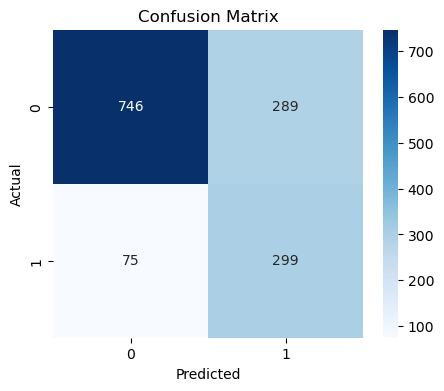

AUC Score: 0.8407682967785269


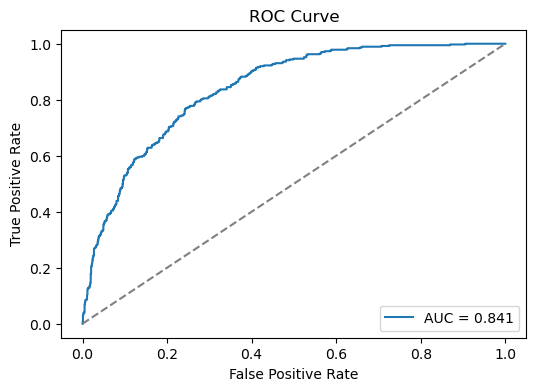


Top Features Influencing Churn:

                                  Feature  Coefficient
6             InternetService_Fiber optic     0.553958
3                            TotalCharges     0.505730
18                    StreamingMovies_Yes     0.195509
23         PaymentMethod_Electronic check     0.192458
16                        StreamingTV_Yes     0.179330
21                   PaperlessBilling_Yes     0.170210
0                           SeniorCitizen     0.063897
24             PaymentMethod_Mailed check     0.016264
4                             Partner_Yes     0.012629
22  PaymentMethod_Credit card (automatic)    -0.000586

Bottom Features (strongest negative coefficients):

                                 Feature  Coefficient
13       TechSupport_No internet service    -0.072925
10      OnlineBackup_No internet service    -0.072925
12  DeviceProtection_No internet service    -0.072925
5                         Dependents_Yes    -0.105251
14                       TechSupport_Y

In [41]:
# Generate class predictions and positive-class probabilities on holdout test set.
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Compute and print core classification metrics.
accuracy = accuracy_score(y_test, y_pred)
print('Holdout Test Performance:')
print('Accuracy:', accuracy)

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

# Build and display confusion matrix.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC curve and calculate AUC.
roc_auc = roc_auc_score(y_test, y_prob)
print('AUC Score:', roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Extract selected features and their logistic coefficients.
selector = final_model.named_steps['selector']
log_reg = final_model.named_steps['classifier']
selected_feature_names = X_train.columns[selector.get_support()]

coefficients = pd.DataFrame({
    'Feature': selected_feature_names,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print('\nTop Features Influencing Churn:\n')
print(coefficients.head(10))

print('\nBottom Features (strongest negative coefficients):\n')
print(coefficients.tail(10))

# Print final summary metrics.
print('\nFinal Model Performance:')
print('Accuracy:', accuracy)
print('AUC Score:', roc_auc)